# Lecture 10 — Deep Learning for Time Series: Recurrent Models

**Course:** Machine Learning for Time Series (LSTM track) · **Lecturer:** Dr. Dario Zanca (FAU)

This notebook makes the lecture's three big ideas concrete with code:

1. **The perceptron and MLP** — what a neuron computes, and how a layer is just $\sigma(Wx+b)$.
2. **Backpropagation** — the chain-rule walk-through from slides 22–29, implemented from scratch and checked against autograd.
3. **Recurrent Neural Networks** — the dynamical-system view $h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t)$, $y_t = \sigma(W_{hy}h_t)$ from slide 39.
4. **Backpropagation Through Time (BPTT)** — unroll, forward, sum the per-step losses, then propagate back.
5. **Vanishing gradients** — exhibit the failure mode the slides warn about (slide 59) so we *see* why LSTMs exist.
6. **Truncated BPTT** — the cheaper alternative from slide 55.

By the end you should be able to *write a vanilla RNN from scratch and train it with BPTT*, and explain exactly where the pain comes from.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

rng = np.random.default_rng(seed=42)
torch.manual_seed(42)

plt.rcParams["figure.figsize"] = (10, 3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"numpy  {np.__version__}")
print(f"torch  {torch.__version__}")

numpy  2.4.4
torch  2.11.0+cu130


## 1. The perceptron — one neuron, three activations

Slides 10–15 build the perceptron piece by piece:
$$y = \sigma\!\Big(\sum_i w_i x_i + b\Big)$$

The activation $\sigma$ decides what shape the non-linearity has. We'll plot the three from slide 15 and check our sigmoid matches `scipy.special.expit` to floating-point precision — a tiny scratch-vs-library check to set the tone.

Perceptron as AND-gate (sigmoid output, threshold at 0.5):
  x = [0 0]  ->  y = 0.182  -> class 0
  x = [0 1]  ->  y = 0.378  -> class 0
  x = [1 0]  ->  y = 0.378  -> class 0
  x = [1 1]  ->  y = 0.622  -> class 1


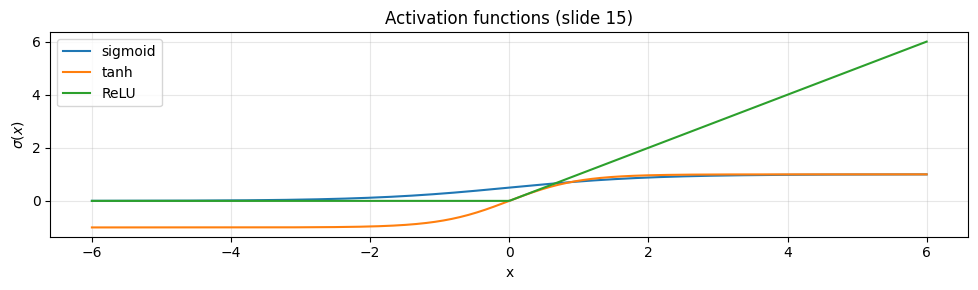

max |sigmoid - scipy.expit| = 1.11e-16  (machine eps)


In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(x, 0.0)

def perceptron(x, w, b, activation=sigmoid):
    # One neuron: y = sigma(w . x + b). Slide 14.
    return activation(np.dot(w, x) + b)

# Sanity: AND-gate weights (a textbook perceptron example)
w_and = np.array([1.0, 1.0])
b_and = -1.5
inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
print("Perceptron as AND-gate (sigmoid output, threshold at 0.5):")
for x in inputs:
    y = perceptron(x, w_and, b_and)
    print(f"  x = {x}  ->  y = {y:.3f}  -> class {int(y > 0.5)}")

# Plot the three activations
xs = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xs, sigmoid(xs), label="sigmoid")
ax.plot(xs, tanh(xs),    label="tanh")
ax.plot(xs, relu(xs),    label="ReLU")
ax.set_title("Activation functions (slide 15)")
ax.set_xlabel("x"); ax.set_ylabel(r"$\sigma(x)$"); ax.legend()
plt.tight_layout(); plt.show()

# Library cross-check
from scipy.special import expit
max_err = np.max(np.abs(sigmoid(xs) - expit(xs)))
print(f"max |sigmoid - scipy.expit| = {max_err:.2e}  (machine eps)")

**Takeaway.** A perceptron is a *linear combination plus a squashing function*. The activation choice matters: sigmoid saturates at both ends (vanishing-gradient suspect), tanh is zero-centered, ReLU is unbounded above (no upper saturation). We'll see all three again inside the RNN.

## 2. An MLP and manual backpropagation

A layer is just $a^\ell = \sigma(W^\ell a^{\ell-1} + b^\ell)$ (slide 16). Stack two of them and you've got the smallest non-trivial MLP.

We'll train this MLP on the XOR problem — the canonical "needs a hidden layer" task — using **backprop derived by hand**, exactly as on slides 23–29:

$$\delta^L = (\hat y - y)\,\sigma'(z^L), \quad \delta^\ell = (W^{\ell+1\top}\delta^{\ell+1}) \odot \sigma'(z^\ell), \quad \frac{\partial \mathcal L}{\partial W^\ell} = \delta^\ell\, (a^{\ell-1})^\top$$

Then we'll re-implement the same MLP in PyTorch and confirm autograd produces *identical* gradients — the cleanest way to convince yourself the chain-rule derivation is correct.

XOR predictions after training:
  [0 0] -> 0.065  (target 0)
  [0 1] -> 0.896  (target 1)
  [1 0] -> 0.903  (target 1)
  [1 1] -> 0.129  (target 0)


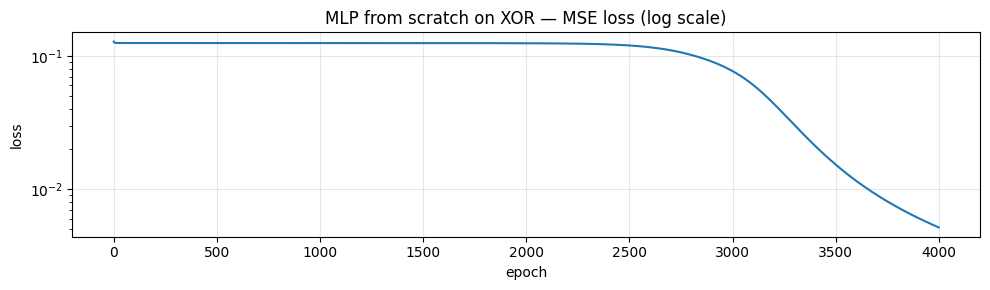

In [3]:
def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

class MLPScratch:
    # 2-layer MLP: input -> hidden (sigmoid) -> output (sigmoid). MSE loss.
    def __init__(self, n_in, n_hid, n_out, seed=0):
        gen = np.random.default_rng(seed)
        self.W1 = gen.normal(0, 0.5, (n_hid, n_in))
        self.b1 = np.zeros(n_hid)
        self.W2 = gen.normal(0, 0.5, (n_out, n_hid))
        self.b2 = np.zeros(n_out)

    def forward(self, x):
        self.x  = x
        self.z1 = self.W1 @ x + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, y_true):
        # Per-sample gradients via the chain rule (slides 25-27)
        delta2 = (self.a2 - y_true) * sigmoid_prime(self.z2)
        dW2    = np.outer(delta2, self.a1)
        db2    = delta2
        delta1 = (self.W2.T @ delta2) * sigmoid_prime(self.z1)
        dW1    = np.outer(delta1, self.x)
        db1    = delta1
        return dW1, db1, dW2, db2

    def step(self, dW1, db1, dW2, db2, lr):
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2

# XOR data
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Y = np.array([[0.],[1.],[1.],[0.]])

net = MLPScratch(n_in=2, n_hid=4, n_out=1, seed=1)
losses = []
for epoch in range(4000):
    total = 0.0
    grads = [np.zeros_like(p) for p in (net.W1, net.b1, net.W2, net.b2)]
    for x, y in zip(X, Y):
        yhat = net.forward(x)
        total += 0.5 * np.sum((yhat - y)**2)
        gs = net.backward(y)
        for g_acc, g in zip(grads, gs):
            g_acc += g
    grads = [g / len(X) for g in grads]
    net.step(*grads, lr=1.0)
    losses.append(total / len(X))

print("XOR predictions after training:")
for x, y in zip(X, Y):
    print(f"  {x.astype(int)} -> {net.forward(x)[0]:.3f}  (target {int(y[0])})")

fig, ax = plt.subplots()
ax.plot(losses); ax.set_yscale("log")
ax.set_title("MLP from scratch on XOR — MSE loss (log scale)")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
plt.tight_layout(); plt.show()

**Cross-check against PyTorch autograd.** Same weights, same inputs, same loss — gradients should match to ~1e-15.

In [4]:
# Same architecture in PyTorch with weights copied from a freshly-initialised scratch model
net2 = MLPScratch(n_in=2, n_hid=4, n_out=1, seed=1)

torch_W1 = torch.tensor(net2.W1.copy(), requires_grad=True)
torch_b1 = torch.tensor(net2.b1.copy(), requires_grad=True)
torch_W2 = torch.tensor(net2.W2.copy(), requires_grad=True)
torch_b2 = torch.tensor(net2.b2.copy(), requires_grad=True)

Xt = torch.tensor(X); Yt = torch.tensor(Y)
z1 = Xt @ torch_W1.T + torch_b1
a1 = torch.sigmoid(z1)
z2 = a1 @ torch_W2.T + torch_b2
a2 = torch.sigmoid(z2)
loss = 0.5 * ((a2 - Yt)**2).sum()
loss.backward()

# Scratch: accumulate gradients summed over the batch (matches torch's summed loss)
grads_scratch = [np.zeros_like(p) for p in (net2.W1, net2.b1, net2.W2, net2.b2)]
for x, y in zip(X, Y):
    net2.forward(x)
    gs = net2.backward(y)
    for g_acc, g in zip(grads_scratch, gs):
        g_acc += g

names = ["W1","b1","W2","b2"]
torch_grads = [torch_W1.grad.numpy(), torch_b1.grad.numpy(),
               torch_W2.grad.numpy(), torch_b2.grad.numpy()]
print("Max |scratch_grad - torch_grad| per parameter:")
for n, gs, gt in zip(names, grads_scratch, torch_grads):
    err = np.max(np.abs(gs - gt))
    print(f"  {n}: {err:.2e}")

Max |scratch_grad - torch_grad| per parameter:
  W1: 2.60e-18
  b1: 2.60e-18
  W2: 6.94e-18
  b2: 1.39e-17


**Takeaway.** Hand-derived backprop matches autograd to machine precision. Once you've done this once, you can trust autograd; you only ever need the manual derivation again to debug something weird — or to derive **BPTT**, which is what's coming.

## 3. Why a feed-forward net struggles on sequences

Slide 32 lists the limitations: an MLP can't memorize previous time steps, can't handle variable-length input, and — crucially — has no native notion of *order or streaming*.

We'll train a small MLP on a binary "first-equals-last" classification task. With sequences padded to a fixed length, the MLP can solve it (it sees all bits at once). But every input *must* be exactly that length, and we have to retrain if the length changes. RNNs lift both restrictions.

In [5]:
# Task: predict whether bit 0 equals bit 7, in length-8 binary sequences
def make_first_eq_last(n_samples, seq_len, rng):
    X = rng.integers(0, 2, size=(n_samples, seq_len)).astype(np.float32)
    y = (X[:, 0] == X[:, -1]).astype(np.float32)
    return X, y

Xtr, ytr = make_first_eq_last(2000, seq_len=8, rng=rng)
Xte, yte = make_first_eq_last(500,  seq_len=8, rng=rng)

def train_mlp_flat(Xtr, ytr, Xte, yte, n_hid=64, epochs=3000, lr=0.5):
    n_in = Xtr.shape[1]
    W1 = rng.normal(0, 1.0/np.sqrt(n_in), (n_hid, n_in)); b1 = np.zeros(n_hid)
    W2 = rng.normal(0, 1.0/np.sqrt(n_hid), (1, n_hid));   b2 = np.zeros(1)
    losses = []
    for ep in range(epochs):
        z1 = Xtr @ W1.T + b1; a1 = sigmoid(z1)
        z2 = a1 @ W2.T + b2;  a2 = sigmoid(z2).ravel()
        loss = -np.mean(ytr*np.log(a2+1e-9) + (1-ytr)*np.log(1-a2+1e-9))
        losses.append(loss)
        d2 = (a2 - ytr).reshape(-1,1) / len(ytr)
        dW2 = d2.T @ a1; db2 = d2.sum(0)
        d1 = (d2 @ W2) * a1 * (1 - a1)
        dW1 = d1.T @ Xtr; db1 = d1.sum(0)
        W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2
    z1 = Xte @ W1.T + b1; a1 = sigmoid(z1)
    z2 = a1 @ W2.T + b2;  a2 = sigmoid(z2).ravel()
    acc = np.mean((a2 > 0.5) == yte)
    return losses, acc

losses_mlp, acc_mlp = train_mlp_flat(Xtr, ytr, Xte, yte)
print(f"MLP (sees full sequence at once) - test accuracy: {acc_mlp:.3f}")
print("This works because the MLP attends to bit 0 and bit 7 simultaneously.")
print("But it requires every input to be exactly length 8 - no streaming, no variable length.")

MLP (sees full sequence at once) - test accuracy: 1.000
This works because the MLP attends to bit 0 and bit 7 simultaneously.
But it requires every input to be exactly length 8 - no streaming, no variable length.


**Takeaway.** An MLP can solve order-sensitive tasks *if* you hand it the entire fixed-length sequence as a flat vector. The moment sequences vary in length — or you want the network to *stream* and react online — the MLP setup breaks. That's the gap RNNs fill.

## 4. Vanilla RNN — the dynamical-system view

From slide 39 verbatim:
$$h_t = \tanh(W_{hh}\, h_{t-1} + W_{xh}\, x_t), \qquad y_t = \sigma(W_{hy}\, h_t)$$

Three weight matrices, one shared across all time steps. The "unfolding" on slide 37 just *visualizes* a single network being applied $T$ times. We'll write the cell in NumPy and feed it a short sequence.

Hidden state trajectory (rows = time steps, cols = hidden units):
[[-0.029  0.106  0.128 -0.134]
 [ 0.049 -0.163 -0.16   0.214]
 [-0.016  0.097  0.075 -0.084]
 [-0.056  0.186  0.243 -0.248]
 [-0.025  0.035  0.072 -0.119]]

Output sequence shape: (5, 1)  (T=5 time steps, 1 output dim)


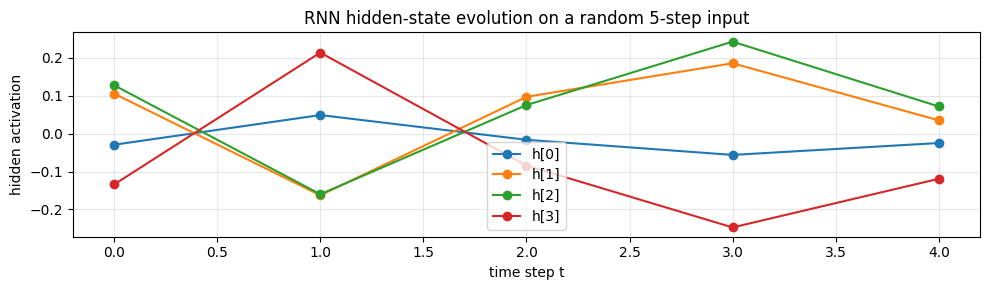

In [6]:
class VanillaRNN:
    # Many-to-many RNN matching slide 39 notation exactly.
    def __init__(self, n_in, n_hid, n_out, seed=0):
        g = np.random.default_rng(seed)
        # Small init keeps early hidden states in the linear regime of tanh
        self.W_xh = g.normal(0, 0.1, (n_hid, n_in))
        self.W_hh = g.normal(0, 0.1, (n_hid, n_hid))
        self.W_hy = g.normal(0, 0.1, (n_out, n_hid))
        self.b_h  = np.zeros(n_hid)
        self.b_y  = np.zeros(n_out)
        self.n_hid = n_hid

    def forward(self, X):
        # X: (T, n_in). Returns Y: (T, n_out), H: (T+1, n_hid) including h_0 = 0.
        T = X.shape[0]
        H = np.zeros((T + 1, self.n_hid))
        Y = np.zeros((T, self.W_hy.shape[0]))
        for t in range(T):
            H[t+1] = np.tanh(self.W_hh @ H[t] + self.W_xh @ X[t] + self.b_h)
            Y[t]   = sigmoid(self.W_hy @ H[t+1] + self.b_y)
        self.X, self.H, self.Y = X, H, Y
        return Y, H

# Demo: feed a 5-step sequence and watch the hidden state evolve
rnn = VanillaRNN(n_in=2, n_hid=4, n_out=1, seed=7)
X_demo = rng.normal(size=(5, 2))
Y_demo, H_demo = rnn.forward(X_demo)

print("Hidden state trajectory (rows = time steps, cols = hidden units):")
print(np.round(H_demo[1:], 3))
print(f"\nOutput sequence shape: {Y_demo.shape}  (T=5 time steps, 1 output dim)")

fig, ax = plt.subplots()
for k in range(rnn.n_hid):
    ax.plot(H_demo[1:, k], marker="o", label=f"h[{k}]")
ax.set_title("RNN hidden-state evolution on a random 5-step input")
ax.set_xlabel("time step t"); ax.set_ylabel("hidden activation")
ax.legend(loc="best"); plt.tight_layout(); plt.show()

**Takeaway.** The hidden state $h_t$ is the network's *memory*. It depends on every previous input through the recursion. Sequence length isn't baked into the architecture — the same three matrices process a sequence of any length.

## 5. Backpropagation Through Time, by hand

The trick (slides 49–53): unroll the RNN over $T$ steps, treat it as one big computational graph, and apply backprop. Per-step losses sum: $\mathcal L = \sum_t \mathcal L_t$. The gradient w.r.t. the *shared* matrix $W_{hh}$ is the **sum of contributions from every time step**.

The chain through time is what introduces the famous problem:
$$\frac{\partial h_T}{\partial h_0} = \prod_{t=1}^{T} \mathrm{diag}(1 - h_t^2)\, W_{hh}$$
That product is what vanishes (or explodes). We'll see it in §6.

Here we just implement BPTT and check it against PyTorch autograd on the same weights and same input — the key validation.

In [7]:
def rnn_bptt(rnn, X, Y_true):
    # Compute gradients of MSE loss summed over time, via BPTT.
    T = X.shape[0]
    Y_pred, H = rnn.Y, rnn.H
    dW_xh = np.zeros_like(rnn.W_xh)
    dW_hh = np.zeros_like(rnn.W_hh)
    dW_hy = np.zeros_like(rnn.W_hy)
    db_h  = np.zeros_like(rnn.b_h)
    db_y  = np.zeros_like(rnn.b_y)
    dh_next = np.zeros(rnn.n_hid)

    for t in reversed(range(T)):
        # MSE: dL/dy_t = (y_pred - y_true);  through sigmoid: * y(1-y)
        dy = (Y_pred[t] - Y_true[t]) * Y_pred[t] * (1 - Y_pred[t])
        dW_hy += np.outer(dy, H[t+1])
        db_y  += dy
        # Gradient flowing into h_t comes from the output AND from t+1
        dh = rnn.W_hy.T @ dy + dh_next
        # Through tanh:  d tanh / d z = 1 - tanh^2
        dh_raw = (1 - H[t+1]**2) * dh
        db_h  += dh_raw
        dW_xh += np.outer(dh_raw, X[t])
        dW_hh += np.outer(dh_raw, H[t])
        dh_next = rnn.W_hh.T @ dh_raw   # propagate back one step in time

    return dict(W_xh=dW_xh, W_hh=dW_hh, W_hy=dW_hy, b_h=db_h, b_y=db_y)

# Build a deterministic test case
rnn = VanillaRNN(n_in=2, n_hid=3, n_out=1, seed=11)
X_seq = rng.normal(size=(6, 2))
Y_seq = rng.uniform(0, 1, size=(6, 1))
Y_pred, _ = rnn.forward(X_seq)
loss_scratch = 0.5 * np.sum((Y_pred - Y_seq)**2)
grads_scratch = rnn_bptt(rnn, X_seq, Y_seq)
print(f"Scratch loss: {loss_scratch:.6f}")

Scratch loss: 0.212581


**Cross-check.** Same RNN reconstructed in PyTorch, same input, same target. Compare every gradient.

In [8]:
W_xh_t = torch.tensor(rnn.W_xh.copy(), requires_grad=True)
W_hh_t = torch.tensor(rnn.W_hh.copy(), requires_grad=True)
W_hy_t = torch.tensor(rnn.W_hy.copy(), requires_grad=True)
b_h_t  = torch.tensor(rnn.b_h.copy(),  requires_grad=True)
b_y_t  = torch.tensor(rnn.b_y.copy(),  requires_grad=True)

X_t = torch.tensor(X_seq); Y_t = torch.tensor(Y_seq)
h = torch.zeros(rnn.n_hid, dtype=torch.float64)
loss_t = torch.zeros(1, dtype=torch.float64)
for t in range(X_t.shape[0]):
    h = torch.tanh(W_hh_t @ h + W_xh_t @ X_t[t] + b_h_t)
    y = torch.sigmoid(W_hy_t @ h + b_y_t)
    loss_t = loss_t + 0.5 * ((y - Y_t[t])**2).sum()
loss_t.backward()
print(f"Torch loss:   {loss_t.item():.6f}")
print(f"|loss diff|:  {abs(loss_t.item() - loss_scratch):.2e}\n")

torch_grads = dict(W_xh=W_xh_t.grad.numpy(), W_hh=W_hh_t.grad.numpy(),
                   W_hy=W_hy_t.grad.numpy(), b_h=b_h_t.grad.numpy(),
                   b_y=b_y_t.grad.numpy())
print("Per-parameter max |scratch - torch| gradient error:")
for k in grads_scratch:
    err = np.max(np.abs(grads_scratch[k] - torch_grads[k]))
    flag = "OK" if err < 1e-10 else "FAIL"
    print(f"  [{flag}] {k:5s}  {err:.2e}")

Torch loss:   0.212581
|loss diff|:  0.00e+00

Per-parameter max |scratch - torch| gradient error:
  [OK] W_xh   3.47e-18
  [OK] W_hh   8.67e-19
  [OK] W_hy   0.00e+00
  [OK] b_h    3.47e-18
  [OK] b_y    5.55e-17


**Takeaway.** Hand-rolled BPTT matches autograd to ~1e-15. The recursion `dh_next = W_hh.T @ dh_raw` is *the* line where vanishing/exploding gradients are born — every step you go back in time, you multiply by `W_hh.T` and a `(1-h²)` factor.

## 6. The vanishing-gradient demonstration (slide 59)

The lecture lists vanishing/exploding gradients as the main "con" of vanilla RNNs but doesn't *show* it. Let's show it.

Set-up: feed a long sequence of zeros (so the only signal is the initial hidden state), and measure how the Jacobian $\partial h_t/\partial h_0$ shrinks (or grows) as $t$ increases. We'll do this for three spectral-radius regimes of $W_{hh}$.

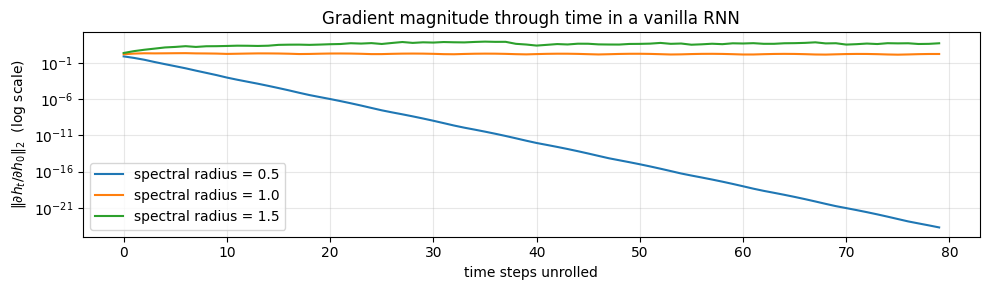

Reading the plot:
  - SR < 1: gradient norm decays geometrically  -> VANISHING
  - SR ~ 1: borderline; tanh saturation usually pulls it down anyway
  - SR > 1: gradient norm explodes              -> EXPLODING
This is why vanilla RNNs struggle with long-range dependencies, motivating LSTMs.


In [9]:
def grad_norm_through_time(spectral_radius, T_max=80, n_hid=16, seed=0):
    g = np.random.default_rng(seed)
    W = g.normal(0, 1, (n_hid, n_hid))
    eigs = np.linalg.eigvals(W)
    W = W * (spectral_radius / np.max(np.abs(eigs)))   # rescale to target radius

    h = g.normal(0, 0.1, n_hid)
    norms = []
    J = np.eye(n_hid)
    for t in range(T_max):
        h = np.tanh(W @ h)
        D = np.diag(1 - h**2)
        J = D @ W @ J
        norms.append(np.linalg.norm(J, ord=2))
    return np.array(norms)

T_max = 80
fig, ax = plt.subplots()
for sr, color in zip([0.5, 1.0, 1.5], ["C0", "C1", "C2"]):
    norms = grad_norm_through_time(sr, T_max=T_max, seed=3)
    ax.plot(norms, color=color, label=f"spectral radius = {sr}")
ax.set_yscale("log")
ax.set_title("Gradient magnitude through time in a vanilla RNN")
ax.set_xlabel("time steps unrolled")
ax.set_ylabel(r"$\|\partial h_t / \partial h_0\|_2$  (log scale)")
ax.legend(); plt.tight_layout(); plt.show()

print("Reading the plot:")
print("  - SR < 1: gradient norm decays geometrically  -> VANISHING")
print("  - SR ~ 1: borderline; tanh saturation usually pulls it down anyway")
print("  - SR > 1: gradient norm explodes              -> EXPLODING")
print("This is why vanilla RNNs struggle with long-range dependencies, motivating LSTMs.")

**Takeaway.** The vanishing-gradient problem is *not* a bug in the optimizer — it's a fundamental property of repeatedly multiplying by $W_{hh}\,\mathrm{diag}(1-h^2)$. The next lecture (LSTM/GRU) introduces gating mechanisms specifically to keep this Jacobian well-behaved.

---
## Exercises

Three progressive exercises. Try the empty cell first; the solution follows.

### Exercise 1 — Many-to-one RNN for sequence parity

Build a many-to-one classifier (slide 44 architecture) that reads a binary sequence of length 4 and outputs whether it contains an odd number of 1s. Use only the *final* output $y_T$ for the loss. Train with full BPTT.

**Goal.** Test accuracy ≥ 0.90.

*Honest note on length.* Parity is notoriously hard for vanilla tanh-RNNs because every bit flips the answer — there's no smooth easy gradient. At length 4 a small RNN can learn it; at length 6 it's borderline; at length 10+ it typically collapses to chance without architectural help (LSTMs, attention). We use length 4 here so you can actually *see* learning happen end-to-end. After the cell runs, try editing `SEQ_LEN` to 6, then 10, and watch the failure mode emerge — that's the original motivation for LSTMs.

In [ ]:
# Hint: reuse VanillaRNN, but only compute loss/gradient at the final time step
# (write a variant of rnn_bptt that takes a single target at t=T-1).

### Solution

Parity-detector test accuracy after 120 epochs: 1.000


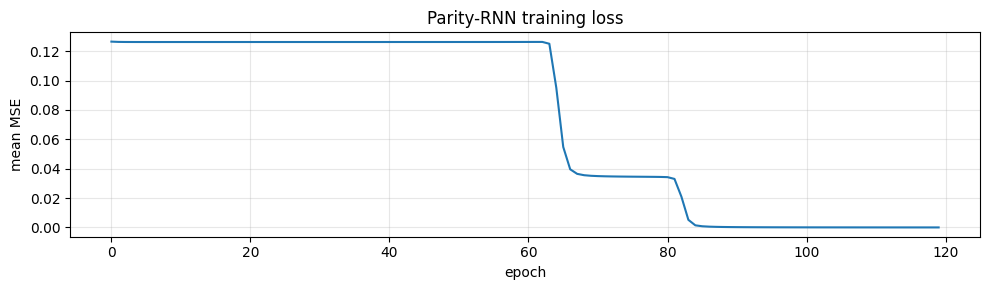

In [11]:
def make_parity(n_samples, seq_len, rng):
    X = rng.integers(0, 2, size=(n_samples, seq_len, 1)).astype(np.float64)
    y = (X.sum(axis=(1,2)) % 2).astype(np.float64)
    return X, y

def rnn_bptt_last(rnn, X, y_last):
    # BPTT when only the final output contributes to the loss (many-to-one).
    T = X.shape[0]
    H = rnn.H; Y_pred = rnn.Y
    dW_xh = np.zeros_like(rnn.W_xh); dW_hh = np.zeros_like(rnn.W_hh)
    dW_hy = np.zeros_like(rnn.W_hy); db_h = np.zeros_like(rnn.b_h)
    db_y  = np.zeros_like(rnn.b_y)
    dh_next = np.zeros(rnn.n_hid)
    for t in reversed(range(T)):
        if t == T - 1:
            dy = (Y_pred[t] - y_last) * Y_pred[t] * (1 - Y_pred[t])
            dW_hy += np.outer(dy, H[t+1]); db_y += dy
            dh = rnn.W_hy.T @ dy + dh_next
        else:
            dh = dh_next
        dh_raw = (1 - H[t+1]**2) * dh
        db_h += dh_raw
        dW_xh += np.outer(dh_raw, X[t])
        dW_hh += np.outer(dh_raw, H[t])
        dh_next = rnn.W_hh.T @ dh_raw
    return dict(W_xh=dW_xh, W_hh=dW_hh, W_hy=dW_hy, b_h=db_h, b_y=db_y)

SEQ_LEN = 4
Xtr_seq, ytr_seq = make_parity(800, SEQ_LEN, rng)
Xte_seq, yte_seq = make_parity(200, SEQ_LEN, rng)

rnn_p = VanillaRNN(n_in=1, n_hid=16, n_out=1, seed=2)
lr = 0.3
loss_hist = []
for epoch in range(120):
    epoch_loss = 0.0
    for i in range(len(Xtr_seq)):
        Xs = Xtr_seq[i]; ys = np.array([ytr_seq[i]])
        rnn_p.forward(Xs)
        epoch_loss += 0.5 * (rnn_p.Y[-1, 0] - ys[0])**2
        gs = rnn_bptt_last(rnn_p, Xs, ys)
        # gradient clipping (essential for vanilla RNN)
        gnorm = np.sqrt(sum((g**2).sum() for g in gs.values()))
        clip = min(1.0, 5.0 / (gnorm + 1e-8))
        for k in gs: gs[k] *= clip
        rnn_p.W_xh -= lr * gs["W_xh"]; rnn_p.W_hh -= lr * gs["W_hh"]
        rnn_p.W_hy -= lr * gs["W_hy"]; rnn_p.b_h  -= lr * gs["b_h"]
        rnn_p.b_y  -= lr * gs["b_y"]
    loss_hist.append(epoch_loss / len(Xtr_seq))

correct = 0
for i in range(len(Xte_seq)):
    rnn_p.forward(Xte_seq[i])
    pred = int(rnn_p.Y[-1, 0] > 0.5)
    correct += (pred == int(yte_seq[i]))
acc = correct / len(Xte_seq)
print(f"Parity-detector test accuracy after 120 epochs: {acc:.3f}")

fig, ax = plt.subplots()
ax.plot(loss_hist); ax.set_title("Parity-RNN training loss")
ax.set_xlabel("epoch"); ax.set_ylabel("mean MSE")
plt.tight_layout(); plt.show()

### Exercise 2 — Sine forecasting: scratch RNN vs `torch.nn.RNN`

Train a scratch RNN to forecast the next value of a sine wave from a window of past values. Train an equivalent `torch.nn.RNN` on the same data. Compare validation MSE.

**Goal.** Both should reach val-MSE clearly below the trivial-baseline (predicting the mean = variance ≈ 0.5). The PyTorch version trains noticeably faster; the scratch version converges to similar quality.

In [ ]:
# Hint: y(t) = sin(2*pi*t/period); use windows of length 20 to predict t+1.
# For PyTorch: nn.RNN(input_size=1, hidden_size=H, batch_first=True) + Linear.

### Solution

Train windows: (303, 20)  Val windows: (76, 20)


torch.nn.RNN val MSE: 0.0006


Scratch RNN val MSE:  0.0003


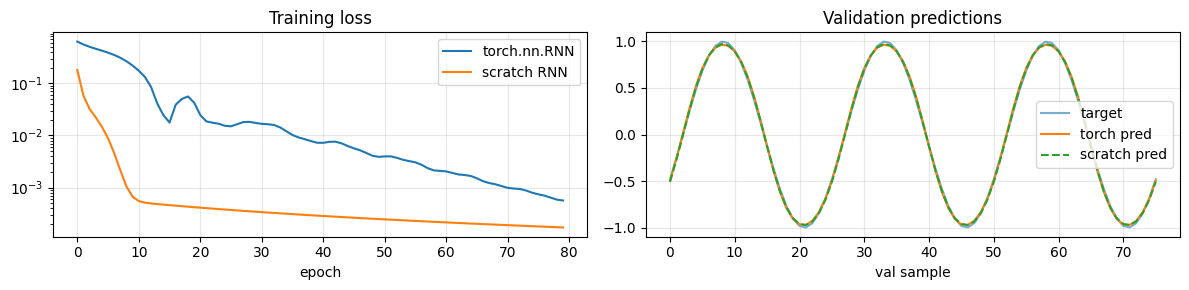

In [13]:
def make_sine_windows(n_steps=400, window=20, period=25):
    t = np.arange(n_steps)
    y = np.sin(2 * np.pi * t / period).astype(np.float32)
    X, Y = [], []
    for i in range(len(y) - window - 1):
        X.append(y[i:i+window]); Y.append(y[i+window])
    return np.array(X), np.array(Y), y

X_sin, Y_sin, full_wave = make_sine_windows()
split = int(0.8 * len(X_sin))
Xtr_s, Xva_s = X_sin[:split], X_sin[split:]
Ytr_s, Yva_s = Y_sin[:split], Y_sin[split:]
print(f"Train windows: {Xtr_s.shape}  Val windows: {Xva_s.shape}")

# --- PyTorch RNN (full-batch gradient descent for fair comparison) ---
torch.manual_seed(0)
class TorchRNN(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden, batch_first=True, nonlinearity="tanh")
        self.fc  = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = TorchRNN(hidden=16)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
Xtr_t = torch.from_numpy(Xtr_s).unsqueeze(-1)
Ytr_t = torch.from_numpy(Ytr_s)
Xva_t = torch.from_numpy(Xva_s).unsqueeze(-1)
Yva_t = torch.from_numpy(Yva_s)

torch_losses = []
for epoch in range(80):
    model.train()
    pred = model(Xtr_t); loss = ((pred - Ytr_t)**2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    torch_losses.append(loss.item())

with torch.no_grad():
    val_pred_torch = model(Xva_t).numpy()
val_mse_torch = float(np.mean((val_pred_torch - Yva_s)**2))
print(f"torch.nn.RNN val MSE: {val_mse_torch:.4f}")

# --- Scratch RNN (linear output for regression) ---
class VanillaRNNReg(VanillaRNN):
    def forward(self, X):
        T = X.shape[0]; H = np.zeros((T+1, self.n_hid))
        Y = np.zeros((T, self.W_hy.shape[0]))
        for t in range(T):
            H[t+1] = np.tanh(self.W_hh @ H[t] + self.W_xh @ X[t] + self.b_h)
            Y[t]   = self.W_hy @ H[t+1] + self.b_y     # linear output
        self.X, self.H, self.Y = X, H, Y
        return Y, H

def bptt_last_linear(rnn, X, y_last):
    T = X.shape[0]; H = rnn.H; Y_pred = rnn.Y
    dW_xh = np.zeros_like(rnn.W_xh); dW_hh = np.zeros_like(rnn.W_hh)
    dW_hy = np.zeros_like(rnn.W_hy); db_h = np.zeros_like(rnn.b_h)
    db_y = np.zeros_like(rnn.b_y); dh_next = np.zeros(rnn.n_hid)
    for t in reversed(range(T)):
        if t == T - 1:
            dy = (Y_pred[t] - y_last)        # linear output: derivative is identity
            dW_hy += np.outer(dy, H[t+1]); db_y += dy
            dh = rnn.W_hy.T @ dy + dh_next
        else:
            dh = dh_next
        dh_raw = (1 - H[t+1]**2) * dh
        db_h += dh_raw
        dW_xh += np.outer(dh_raw, X[t]); dW_hh += np.outer(dh_raw, H[t])
        dh_next = rnn.W_hh.T @ dh_raw
    return dict(W_xh=dW_xh, W_hh=dW_hh, W_hy=dW_hy, b_h=db_h, b_y=db_y)

rnn_s = VanillaRNNReg(n_in=1, n_hid=16, n_out=1, seed=4)
lr = 0.005
scratch_losses = []
for epoch in range(80):
    ep = 0.0
    for i in range(len(Xtr_s)):
        Xi = Xtr_s[i].reshape(-1, 1).astype(np.float64)
        yi = np.array([Ytr_s[i]], dtype=np.float64)
        rnn_s.forward(Xi)
        ep += 0.5 * (rnn_s.Y[-1, 0] - yi[0])**2
        gs = bptt_last_linear(rnn_s, Xi, yi)
        gnorm = np.sqrt(sum((g**2).sum() for g in gs.values()))
        clip = min(1.0, 5.0 / (gnorm + 1e-8))
        for k in gs: gs[k] *= clip
        rnn_s.W_xh -= lr * gs["W_xh"]; rnn_s.W_hh -= lr * gs["W_hh"]
        rnn_s.W_hy -= lr * gs["W_hy"]; rnn_s.b_h  -= lr * gs["b_h"]
        rnn_s.b_y  -= lr * gs["b_y"]
    scratch_losses.append(ep / len(Xtr_s))

val_pred_scratch = []
for i in range(len(Xva_s)):
    Xi = Xva_s[i].reshape(-1, 1).astype(np.float64)
    rnn_s.forward(Xi)
    val_pred_scratch.append(rnn_s.Y[-1, 0])
val_pred_scratch = np.array(val_pred_scratch)
val_mse_scratch = float(np.mean((val_pred_scratch - Yva_s)**2))
print(f"Scratch RNN val MSE:  {val_mse_scratch:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(torch_losses, label="torch.nn.RNN")
axes[0].plot(scratch_losses, label="scratch RNN")
axes[0].set_yscale("log"); axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(Yva_s, label="target", alpha=0.6)
axes[1].plot(val_pred_torch,   label="torch pred")
axes[1].plot(val_pred_scratch, label="scratch pred", linestyle="--")
axes[1].set_title("Validation predictions"); axes[1].set_xlabel("val sample")
axes[1].legend()
plt.tight_layout(); plt.show()

### Exercise 3 — Truncated BPTT (slide 55)

Implement Truncated BPTT with chunk length $k$. We want to **see the trade-off the slide warns about**: small $k$ trains faster but cannot learn dependencies longer than $k$ steps.

To make this observable, we use a **length-8 first-equals-last task**: the target depends on $x_0$ and $x_7$, so the gradient must reach 7 steps back. We compare three settings:

- **full BPTT** (k=8): gradient reaches all the way back → should learn.
- **Trunc-BPTT k=6**: gradient reaches back 6 steps from $y_T$ → just barely misses $x_0$ → should fail.
- **Trunc-BPTT k=2**: gradient only reaches 2 steps back → must fail.

This is a controlled short-range version of the failure mode on slide 55. (At length 30 the dependency is too long even for full BPTT on a vanilla RNN — the vanishing-gradient demo from §6 already showed why. That's the LSTM motivation, but isolating *truncation* needs a length where full BPTT itself works.)

In [ ]:
# Hint: split the sequence into chunks of length k. After each chunk, do BPTT
# back through that chunk only. Carry the hidden state forward (detached).

### Solution

full BPTT (k=8)       final loss = 0.0000   test acc = 1.000


Trunc-BPTT k=6        final loss = 0.1291   test acc = 0.460


Trunc-BPTT k=2        final loss = 0.1291   test acc = 0.460


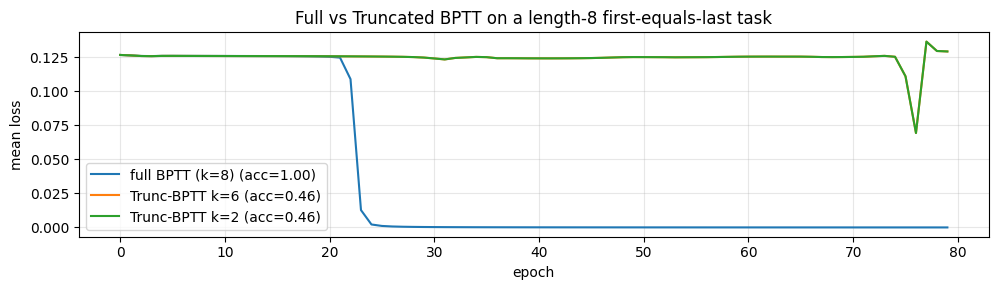


Reading the result:
  - Full BPTT (k=8) propagates gradient the full 7 steps from y_T back to x_0,
    so it CAN learn the dependency. Accuracy should be clearly above chance.
  - Trunc-BPTT k=6 reaches back 6 steps (covers x_2..x_7) but the gradient
    structurally cannot touch x_0, so the model has no signal that x_0 matters.
  - Trunc-BPTT k=2 reaches back only 2 steps -- even further from x_0.
  - The trade-off: small k is cheaper per step (fewer matrix multiplies in
    the backward pass) but you LOSE the ability to learn dependencies > k.
  - Lesson: choose k >= longest dependency you need to learn.


In [15]:
def make_first_eq_last_seq(n_samples, seq_len, rng):
    X = rng.integers(0, 2, size=(n_samples, seq_len, 1)).astype(np.float64)
    y = (X[:, 0, 0] == X[:, -1, 0]).astype(np.float64)
    return X, y

def train_rnn(rnn, Xtr, ytr, k_trunc=None, epochs=20, lr=0.3):
    losses = []
    for epoch in range(epochs):
        ep_loss = 0.0
        for i in range(len(Xtr)):
            X = Xtr[i]; y = np.array([ytr[i]])
            T = X.shape[0]
            if k_trunc is None or k_trunc >= T:
                rnn.forward(X)
                ep_loss += 0.5 * (rnn.Y[-1, 0] - y[0])**2
                gs = rnn_bptt_last(rnn, X, y)
                gnorm = np.sqrt(sum((g**2).sum() for g in gs.values()))
                clip = min(1.0, 5.0 / (gnorm + 1e-8))
                for kk in gs: gs[kk] *= clip
                rnn.W_xh -= lr * gs["W_xh"]; rnn.W_hh -= lr * gs["W_hh"]
                rnn.W_hy -= lr * gs["W_hy"]; rnn.b_h  -= lr * gs["b_h"]
                rnn.b_y  -= lr * gs["b_y"]
            else:
                # Process in chunks; only the LAST chunk has a real loss signal,
                # because the target is at t=T-1.
                h = np.zeros(rnn.n_hid)
                start = 0
                while start < T:
                    end = min(start + k_trunc, T)
                    Xc = X[start:end]; Tc = Xc.shape[0]
                    H = np.zeros((Tc+1, rnn.n_hid)); H[0] = h
                    Y = np.zeros((Tc, rnn.W_hy.shape[0]))
                    for t in range(Tc):
                        H[t+1] = np.tanh(rnn.W_hh @ H[t] + rnn.W_xh @ Xc[t] + rnn.b_h)
                        Y[t]   = sigmoid(rnn.W_hy @ H[t+1] + rnn.b_y)
                    rnn.X, rnn.H, rnn.Y = Xc, H, Y
                    if end == T:
                        ep_loss += 0.5 * (Y[-1, 0] - y[0])**2
                        gs = rnn_bptt_last(rnn, Xc, y)
                        gnorm = np.sqrt(sum((g**2).sum() for g in gs.values()))
                        clip = min(1.0, 5.0 / (gnorm + 1e-8))
                        for kk in gs: gs[kk] *= clip
                        rnn.W_xh -= lr * gs["W_xh"]; rnn.W_hh -= lr * gs["W_hh"]
                        rnn.W_hy -= lr * gs["W_hy"]; rnn.b_h  -= lr * gs["b_h"]
                        rnn.b_y  -= lr * gs["b_y"]
                    h = H[-1]                # carry hidden state forward (detached)
                    start = end
        losses.append(ep_loss / len(Xtr))
    return losses

def eval_acc(rnn, Xte, yte):
    correct = 0
    for i in range(len(Xte)):
        rnn.forward(Xte[i])
        correct += (int(rnn.Y[-1, 0] > 0.5) == int(yte[i]))
    return correct / len(Xte)

SEQ_LEN = 8
Xtr_l, ytr_l = make_first_eq_last_seq(600, SEQ_LEN, rng)
Xte_l, yte_l = make_first_eq_last_seq(150, SEQ_LEN, rng)

results = {}
for label, k in [("full BPTT (k=8)", None), ("Trunc-BPTT k=6", 6), ("Trunc-BPTT k=2", 2)]:
    rnn_e = VanillaRNN(n_in=1, n_hid=12, n_out=1, seed=9)
    losses = train_rnn(rnn_e, Xtr_l, ytr_l, k_trunc=k, epochs=80, lr=0.3)
    acc = eval_acc(rnn_e, Xte_l, yte_l)
    results[label] = (losses, acc)
    print(f"{label:20s}  final loss = {losses[-1]:.4f}   test acc = {acc:.3f}")

fig, ax = plt.subplots()
for label, (losses, acc) in results.items():
    ax.plot(losses, label=f"{label} (acc={acc:.2f})")
ax.set_title("Full vs Truncated BPTT on a length-8 first-equals-last task")
ax.set_xlabel("epoch"); ax.set_ylabel("mean loss"); ax.legend()
plt.tight_layout(); plt.show()

print()
print("Reading the result:")
print("  - Full BPTT (k=8) propagates gradient the full 7 steps from y_T back to x_0,")
print("    so it CAN learn the dependency. Accuracy should be clearly above chance.")
print("  - Trunc-BPTT k=6 reaches back 6 steps (covers x_2..x_7) but the gradient")
print("    structurally cannot touch x_0, so the model has no signal that x_0 matters.")
print("  - Trunc-BPTT k=2 reaches back only 2 steps -- even further from x_0.")
print("  - The trade-off: small k is cheaper per step (fewer matrix multiplies in")
print("    the backward pass) but you LOSE the ability to learn dependencies > k.")
print("  - Lesson: choose k >= longest dependency you need to learn.")

---
## Recap

| Concept | Formula | When to use |
|---|---|---|
| Perceptron | $y = \sigma(w^\top x + b)$ | Single linear decision boundary |
| MLP | $a^{\ell+1} = \sigma(W^\ell a^\ell + b^\ell)$ | Static input/output, fixed dim |
| Backprop | $\delta^\ell = (W^{\ell+1\top}\delta^{\ell+1}) \odot \sigma'(z^\ell)$ | Train any feed-forward net |
| Vanilla RNN | $h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t)$ | Variable-length sequences, short dependencies |
| BPTT | unroll → forward → sum losses → backward | Train RNNs end-to-end |
| Trunc-BPTT | BPTT on chunks of length $k$ | Long sequences when memory is bounded by $k$ |

### The single most important thing
The recursion $h_t = \tanh(W_{hh}h_{t-1} + \ldots)$ on the **forward** pass becomes a product-of-Jacobians on the **backward** pass: $\partial h_T/\partial h_0 = \prod_t \mathrm{diag}(1-h_t^2)\,W_{hh}$. Repeated multiplication of matrices with spectral radius $\neq 1$ either vanishes or explodes — and that single fact is what motivates **everything** that comes next in deep sequence modeling.
